# FIE463 - Group Term Paper 1

In [1]:
# Libraries
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, minimize_scalar

## Part 1

In [2]:
# 1. Parameters
@dataclass
class Parameters:
    """
    Model parameters
    """

    beta: float = .99**30           # Discount factor
    gamma: float = 2.1              # Relative risk aversion
    tau: float = .3                 # Payroll tax rate
    phi: float = .5                 # Fraction of wealth bequeathed by old capitalists
    alpha: float = .36              # Capital share in production
    delta: float = 1 - .94**30      # Capital depreciation rate
    z: float = 1.0                  # Total factor productivity
    N_w: float = .8                 # Fraction of workers
    N_k: float = .2                 # Fraction of capitalists
    tau_a: float = .05              # Wealth tax rate (Added in Part 4)
    pi_a: float = .5                # Probability of wealth tax being implemented in the next period (Added in Part 6)

In [3]:
# Parameter instance
par = Parameters()

In [4]:
# Interim function to compute prices, labor, capital-labor ratio given capital stock K
def compute_prices(K, par:Parameters):
    """
    Compute prices given capital level K.
    These are derived from the firm's first order conditions.
    """
    # Labor supply
    L = .5 * par.N_w

    # Capital-labor ratio
    k = K / L
    # Wage
    w = (1 - par.alpha) * par.z * k**par.alpha

    # Interest rate
    r = par.alpha * par.z * k**(par.alpha - 1) - par.delta

    return L, k, w, r

In [5]:
# 2. Euler error function (With choice of wealth tax or not added in Part 4)
def euler_err(K_next, K, par: Parameters, wealth_tax=False):
    """
    Compute the capitalists' Euler equation error for a given capital stock today and tomorrow
    """
    # Compute prices, labor and capital-labor ratio for today and tomorrow
    L, k, w, r = compute_prices(K, par)
    L_next, k_next, w_next, r_next = compute_prices(K_next, par)

    # Asset market clearing (pre means t-1)
    a_pre = K / (.5 * par.N_k)
    a_t = K_next / (.5 * par.N_k)

    # Evaluate wealth tax transfer
    tau_a = par.tau_a if wealth_tax else 0

    # Transfers from wealth tax (evaluates to 0 if tau_a = 0) (time subscripts: t for today, t1 for tomorrow)
    T_at = tau_a * (1 + r) * K
    T_at1 = tau_a * (1 + r_next) * K_next

    # Intergenerational transfer based on wealth tax rate and returns on assets previous period
    b_t = par.phi * (1 - tau_a) * (1 + r) * a_pre

    # Euler error consumption values (T's are 0 if no wealth tax, and (1 - tau_a) factor is 1 if no wealth tax, so this works for both cases)
    c_ky = b_t + T_at - a_t                                              
    c_ko = (1 - par.phi) * (1 - tau_a) * (1 + r_next) * a_t + T_at1     

    # Guard against invalid consumption (Might happen at too large K and K_next)
    if c_ky <= 0 or c_ko <= 0:
        # Large positive error: root-finders will avoid this region
        return 1e6

    # Euler error (LHS - RHS)
    LHS = c_ky**(-par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - tau_a) * (1 - par.phi) * c_ko**(-par.gamma)
    euler_error = LHS - RHS
    
    return euler_error

In [6]:
# For Part 6: Euler error function under uncertainty about wealth tax (UNCERTAINTY ONLY ENTERS IN RHS)
def euler_err_uncertain(K_next, K, par: Parameters, wealth_tax=False):
    """
    Compute the capitalists' Euler equation error for a given capital stock today and tomorrow, under uncertainty about wealth tax.
    """
    # Wage and rate from Cobb-Douglas production function - This period and next
    L, k, w, r = compute_prices(K, par)
    L_next, k_next, w_next, r_next = compute_prices(K_next, par)

    # Asset market clearing (pre means t-1)
    a_pre = K / (.5 * par.N_k)
    a_t = K_next / (.5 * par.N_k)

    # Transfer from wealth tax is certain today, uncertain next period (no-tax case = 0, so it doesn't strictly need to be defined)
    T_at = par.tau_a * (1 + r) * K
    T_at1 = par.tau_a * (1 + r_next) * K_next

    # Intergenerational transfer is certain
    b_t = par.phi * (1 - par.tau_a) * (1 + r) * a_pre

    # Consumption values 
    c_ky = b_t + T_at - a_t
    # old age consumption dependent on wealth tax. need to compute both cases for expected marginal utility in RHS of Euler equation                                              
    c_ko_tax = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a_t + T_at1    
    c_ko_no_tax = (1 - par.phi) * (1 - 0) * (1 + r_next) * a_t

    # Guard against invalid consumption
    if c_ky <= 0 or c_ko_tax <= 0 or c_ko_no_tax <= 0:
        return 1e6

    # Expected marginal utility of consumption in old age depends on probability of wealth tax being implemented
    exp_term = par.pi_a * (1 - par.tau_a) * c_ko_tax**(-par.gamma) \
          + (1 - par.pi_a) * (1 - 0) * c_ko_no_tax**(-par.gamma)
   
   # Euler error under uncertainty (LHS - RHS)
    LHS = c_ky**(-par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.phi) * exp_term
    euler_error = LHS - RHS
    
    return euler_error

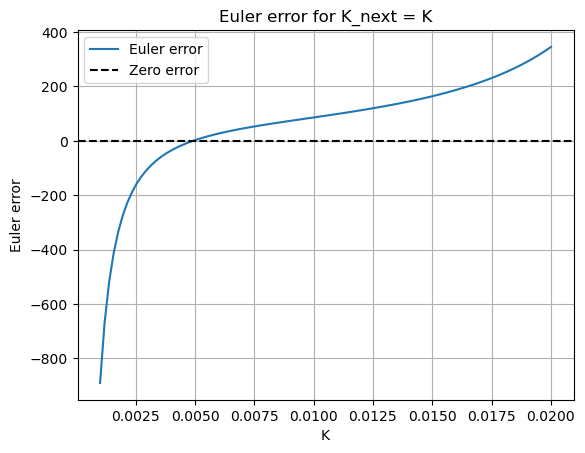

In [7]:
# 3. Plot euler error for a grid of capital levels K to verify that the function has a root, assuming K_(t+1) = K_t
K_grid = np.linspace(0.001, 0.02, 100)
# Values of K on this grid are very small, but that follows from large delta and 30-year periods.
euler_errors = [euler_err(K, K, par, wealth_tax=False) for K in K_grid]

# Plot Euler error for K_next = K, to verify that the function has a root (i.e. that there is a K such that Euler error = 0)
plt.plot(K_grid, euler_errors, label='Euler error')
plt.axhline(0, color='k', linestyle='--', label='Zero error')
plt.xlabel('K')
plt.ylabel('Euler error')
plt.title('Euler error for K_next = K')
plt.legend()
_ = plt.grid()

Root seems to sit around or at K = 0.0050

... Explain why larger grid is problematic in this model ...

## Part 2

In [8]:
# 1. Define dataclass for steady state values
@dataclass
class SteadyState:
    """
    Storing steady state values. 
    """
    par: Parameters = None         # Parameters to compute equilibrium
    K: float = None                # Steady-state aggregate capital
    L: float = None                # Steady-state labor supply
    k: float = None                # Steady-state capital-labor ratio
    w: float = None                # Steady-state wage
    r: float = None                # Steady-state interest rate
    r_annual: float = None         # Steady-state ANNUALIZED interest rate
    Y: float = None                # Steady-state output
    c_wy: float = None             # Steady-state consumption of young workers
    c_wo: float = None             # Steady-state consumption of old workers
    a: float = None                # Steady-state asset holdings per young capitalist
    b: float = None                # Steady-state bequests per young capitalist
    c_ky: float = None             # Steady-state consumption of young capitalists
    c_ko: float = None             # Steady-state consumption of old capitalists
    s: float = None                # Steady-state savings rate
    T_a: float = None              # Steady-state wealth tax transfer (per household == aggregate since N == 1)


In [9]:
# 2. Function to compute the steady state. Choice of wealth tax added in Part 4, uncertainty added in Part 6
def compute_steady_state(par: Parameters, wealth_tax=False, uncertainty=False):
    """
    Compute the steady state of the model given parameters.
    """
    # Bracket for root finding, based on the plot of Euler errors
    bracket = (0.001, 0.02)  

    # Define objective function, choices wealth_tax and uncertainty pass through from overall function call, K_next = K for steady state
    def objective(K):
        # We need a different euler error function for uncertainty compared to no uncertainty.
        if uncertainty:
            return euler_err_uncertain(K, K, par)
        else:
            return euler_err(K, K, par, wealth_tax=wealth_tax)
        
    # Find the root of the Euler error function
    result = root_scalar(
        objective,  
        bracket=bracket, 
        method='bisect'
        )
    
    # Check if root finding was successful
    if not result.converged:
        raise ValueError("Root finding did not converge. Try adjusting the bracket or check the Euler error function.")
    
    # Steady-state capital K_star is the root found
    K_star = result.root 

    # Wealth tax or not
    tau_a = par.tau_a if wealth_tax else 0

    # SteadyState instance to store results
    eq = SteadyState(par=par, K=K_star)

    # Compute prices and other variables at the steady state
    eq.L, eq.k, eq.w, eq.r = compute_prices(eq.K, par)
    eq.Y = par.z * eq.K**par.alpha * (eq.L)**(1 - par.alpha)
    eq.T_a = tau_a * (1 + eq.r) * eq.K
    eq.c_wy = (1 - par.tau) * eq.w + eq.T_a
    eq.c_wo = par.tau * eq.w + eq.T_a
    eq.a = eq.K / (.5 * par.N_k)
    eq.b = par.phi * (1 + eq.r) * (1 - tau_a) * eq.a
    eq.c_ky = eq.b - eq.a + eq.T_a
    eq.c_ko = (1 - par.phi) * (1 - tau_a) * (1 + eq.r) * eq.a + eq.T_a 
    eq.s = eq.a / (eq.b + eq.T_a)

    eq.r_annual = (1 + eq.r)**(1/30) - 1

    # Goods market clearing check
    lhs = eq.Y + (1 - par.delta) * eq.K
    rhs = .5 * par.N_w * (eq.c_wy + eq.c_wo) + .5 * par.N_k * (eq.c_ky + eq.c_ko + eq.a)

    if abs(lhs - rhs) > 1e-6:
        print("Warning: Goods market clearing condition not satisfied.")
        print(f"LHS: {lhs}, RHS: {rhs}")

    return eq

In [10]:
# Define function to print steady state values in a readable format
def print_steady_state(eq: SteadyState):
    """
    Print the steady state values in a readable format. 
    """
    print("Steady State Values:")
    print(' Values specified in question:')
    print(f"    Output (Y): {eq.Y:.4f}")
    print(f"    Capital (K): {eq.K:.4f}")
    print(f"    Wage (w): {eq.w:.4f}")
    print(f"    Interest Rate (r): {eq.r:.4%}")
    print(f"    Annualized Interest Rate: {eq.r_annual:.4%}")
    print(f"    Consumption of Young Workers (c_wy): {eq.c_wy:.4f}")
    print(f"    Consumption of Old Workers (c_wo): {eq.c_wo:.4f}")
    print(f"    Consumption of Young Capitalists (c_ky): {eq.c_ky:.4f}")
    print(f"    Consumption of Old Capitalists (c_ko): {eq.c_ko:.4f}")
    print(f"    Asset Holdings per Young Capitalist (a): {eq.a:.4f}")
    print(f"    Savings Rate (s): {eq.s:.4%}")

    print('-----------------------------')
    print(' Other values')
    print(f"    Labor (L): {eq.L:.4f} (Determined by model, only dependent on N_w)")
    print(f"    Capital-Labor Ratio (k): {eq.k:.4f}")
    print(f"    Bequests per Young Capitalist (b): {eq.b:.4f}")
    
    # Only print wealth tax transfer if it is implemented (non-zero)
    if eq.T_a == 0:
        print("    No wealth tax implemented.")
    else:
        print(f"    Wealth Tax Transfer per Household (T_a): {eq.T_a:.4f}")

In [11]:
# 3. Compute and report steady state values
eq = compute_steady_state(par, wealth_tax=False, uncertainty=False)
print_steady_state(eq)

Steady State Values:
 Values specified in question:
    Output (Y): 0.0821
    Capital (K): 0.0049
    Wage (w): 0.1314
    Interest Rate (r): 516.2944%
    Annualized Interest Rate: 6.2493%
    Consumption of Young Workers (c_wy): 0.0920
    Consumption of Old Workers (c_wo): 0.0394
    Consumption of Young Capitalists (c_ky): 0.1025
    Consumption of Old Capitalists (c_ko): 0.1517
    Asset Holdings per Young Capitalist (a): 0.0492
    Savings Rate (s): 32.4520%
-----------------------------
 Other values
    Labor (L): 0.4000 (Determined by model, only dependent on N_w)
    Capital-Labor Ratio (k): 0.0123
    Bequests per Young Capitalist (b): 0.1517
    No wealth tax implemented.


## Part 3

In [12]:
# 1. Create Simulation dataclass to store time paths of variables
@dataclass
class Simulation:
    par: Parameters                 # Model Parameters
    T: int                          # Number of periods to simulate
    
    K_path: np.ndarray
    r_path: np.ndarray
    w_path: np.ndarray
    Y_path: np.ndarray
    c_wy_path: np.ndarray
    c_wo_path: np.ndarray
    a_path: np.ndarray
    b_path: np.ndarray
    c_ky_path: np.ndarray
    c_ko_path: np.ndarray
    s_path: np.ndarray              # Savings rate s = a/b

In [13]:
# 2. Function to simulate transition paths, wealth_tax added in Part 4, uncertainty added in Part 6
def simulate_olg(K0, T, par: Parameters, wealth_tax=False, uncertainty=False) -> Simulation:
    """
    Simulate the transition paths of the model starting from an initial capital stock K0 for T periods.
    """
    # allocate arrays
    K_path   = np.zeros(T)
    r_path   = np.zeros(T)
    w_path   = np.zeros(T)
    Y_path   = np.zeros(T)
    c_wy_path = np.zeros(T)
    c_wo_path = np.zeros(T)
    a_path    = np.zeros(T)
    b_path    = np.zeros(T)
    c_ky_path = np.zeros(T)
    c_ko_path = np.zeros(T)
    s_path    = np.zeros(T)

    # set initial capital
    K_path[0] = K0
    # Set wealth tax or not
    tau_a = par.tau_a if wealth_tax else 0

    # Define objective function for root finder based on uncertainty or not regarding wealth tax
    def objective(K_next):
        if uncertainty:
            return euler_err_uncertain(K_next, K_path[t], par)
        else:
            return euler_err(K_next, K_path[t], par, wealth_tax=wealth_tax)

    # simulate every period except last
    for t in range(T - 1):
        L, k, w, r = compute_prices(K_path[t], par)
        r_path[t] = r
        w_path[t] = w
        Y_path[t] = par.z * K_path[t]**par.alpha * L**(1 - par.alpha)
        T_at = tau_a * (1 + r) * K_path[t]
        c_wy_path[t] = (1 - par.tau) * w + T_at
        c_wo_path[t] = par.tau * w + T_at
        a_path[t] = K_path[t] / (0.5 * par.N_k)
        b_path[t] = par.phi * (1 - tau_a) * (1 + r) * a_path[t]
        c_ky_path[t] = b_path[t] - a_path[t] + T_at
        c_ko_path[t] = (1 - par.phi) * (1 - tau_a) * (1 + r) * a_path[t] + T_at
        s_path[t] = a_path[t] / (b_path[t] + T_at)

        # Checking goods market clearing inside loop
        lhs = Y_path[t] + (1 - par.delta) * K_path[t]
        rhs = 0.5 * par.N_w * (c_wy_path[t] + c_wo_path[t]) \
        + 0.5 * par.N_k * (c_ky_path[t] + c_ko_path[t] + a_path[t])
        # Prints only if there is a mismatch
        if abs(lhs - rhs) > 1e-8:
            print(f"Goods market mismatch at t={t}: {lhs - rhs}")

        # root for K_next
        result = root_scalar(
            objective,
            bracket=(0.001, 0.02),
            method='bisect'
        )
        # Check if root finding was successful
        if not result.converged:
            raise ValueError(f"Root finding did not converge at time {t}.")
        K_path[t+1] = result.root

    # last period
    L, k, w, r = compute_prices(K_path[T-1], par)
    r_path[T-1] = r
    w_path[T-1] = w
    Y_path[T-1] = par.z * K_path[T-1]**par.alpha * L**(1 - par.alpha)
    T_at = tau_a * (1 + r) * K_path[T-1]
    c_wy_path[T-1] = (1 - par.tau) * w + T_at
    c_wo_path[T-1] = par.tau * w + T_at
    a_path[T-1] = K_path[T-1] / (0.5 * par.N_k)
    b_path[T-1] = par.phi * (1 - tau_a) * (1 + r) * a_path[T-1]
    c_ky_path[T-1] = b_path[T-1] - a_path[T-1] + T_at
    c_ko_path[T-1] = (1 - par.phi) * (1 - tau_a) * (1 + r) * a_path[T-1] + T_at
    s_path[T-1] = a_path[T-1] / (b_path[T-1] + T_at)

    # build Simulation object
    sim = Simulation(
        par=par, T=T,
        K_path=K_path, r_path=r_path, w_path=w_path, Y_path=Y_path,
        c_wy_path=c_wy_path, c_wo_path=c_wo_path,
        a_path=a_path, b_path=b_path,
        c_ky_path=c_ky_path, c_ko_path=c_ko_path,
        s_path=s_path
    )
    
    return sim

In [14]:
# 3. Verify by starting at half the steady-state capital
eq = compute_steady_state(par)
K0 = eq.K / 2  # Start with half of the steady-state capital to see a transition

sim = simulate_olg(K0, T=20, par=par)
print("Simulated capital path:\n", sim.K_path)

Simulated capital path:
 [0.00246113 0.00352527 0.0041906  0.0045546  0.00474127 0.00483405
 0.00487949 0.00490157 0.00491226 0.00491744 0.00491993 0.00492114
 0.00492172 0.00492201 0.00492214 0.00492221 0.00492224 0.00492225
 0.00492226 0.00492227]


In [15]:
# 4. Function to plot transition paths
def plot_simulation(eq_old: SteadyState, sim: Simulation, eq_new: SteadyState | None = None, wealth_tax=False, uncertainty=False):
    """
    Plot selected transition paths. If eq_new is given, show both old and new SS.
    """
    # initialize subplots
    fig, ax = plt.subplots(5, 2, figsize=(15, 12))

    # Define variables to plot: (series, title, old SS, new SS if True, plot as % deviation from old SS if True)
    variables = [
        (sim.Y_path,   'Output $Y_t$',   eq_old.Y,   eq_new.Y if eq_new else None, True),
        (sim.K_path,   'Capital $K_t$',  eq_old.K,   eq_new.K if eq_new else None, True),
        (sim.w_path,   'Wage $w_t$',     eq_old.w,   eq_new.w if eq_new else None, True),
        (sim.r_path,   'Interest rate $r_t$', eq_old.r, eq_new.r if eq_new else None, False),
        (sim.b_path,   'Bequests per young capitalist $b_t$', eq_old.b, eq_new.b if eq_new else None, True),
        (sim.s_path,   'Savings rate $s_t$', eq_old.s, eq_new.s if eq_new else None, False),
        (sim.c_wy_path,'Young workers $c^w_{y,t}$', eq_old.c_wy, eq_new.c_wy if eq_new else None, True),
        (sim.c_wo_path,'Old workers $c^w_{o,t}$',   eq_old.c_wo, eq_new.c_wo if eq_new else None, True),
        (sim.c_ky_path,'Young capitalists $c^k_{y,t}$', eq_old.c_ky, eq_new.c_ky if eq_new else None, True),
        (sim.c_ko_path,'Old capitalists $c^k_{o,t}$',   eq_old.c_ko, eq_new.c_ko if eq_new else None, True),
    ]

    # Assign time grid
    T = sim.T
    tgrid = np.arange(T)

    # Loop over variables and plot
    for i, (series, title, ss_old, ss_new, as_pct_dev) in enumerate(variables):
        # Determine subplot location
        row, col = divmod(i, 2)

        # This block plots percent deviations from old/new SS, and old SS as horizontal line at 0
        if as_pct_dev:
            pct_dev = 100 * (series - ss_old) / ss_old
            ax[row, col].plot(tgrid, pct_dev, marker='o', label='Path')
            ax[row, col].axhline(0, color='orange', linestyle='--',
                                 linewidth=1, label='Old SS')
            # Plots new SS in case of wealth tax or uncertainty shock
            if ss_new is not None:
                dev_new = 100 * (ss_new - ss_old) / ss_old
                ax[row, col].axhline(dev_new, color='red', linestyle='--',
                                     linewidth=1, label='New SS')
            ax[row, col].set_ylabel('% deviation from old SS')
        # This block plots percent levels, as well as old SS (and new SS if True) as horizontal lines
        else:
            ax[row, col].plot(tgrid, 100 * series, marker='o', label='Path')
            ax[row, col].axhline(100 * ss_old, color='orange', linestyle='--',
                                 linewidth=1, label='Old SS')
            # Plots new SS in case of wealth tax or uncertainty shock
            if ss_new is not None:
                ax[row, col].axhline(100 * ss_new, color='red', linestyle='--',
                                     linewidth=1, label='New SS')
            ax[row, col].set_ylabel('Percent (%)')
        # Set title, labels, and grid for each subplot
        ax[row, col].set_title(title)
        ax[row, col].set_xlabel('Time')
        ax[row, col].grid(True)

    # Only one legend needed, for path and SS lines by color and style
    ax[0, 0].legend()

    # Overall title dependent on shock type
    if wealth_tax:
        fig.suptitle('Transition paths with wealth tax shock', fontsize=16)
    elif uncertainty:
        fig.suptitle('Transition paths with uncertainty shock, no actual wealth tax', fontsize=16)
    else:
        fig.suptitle('Transition paths without shocks', fontsize=16)

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

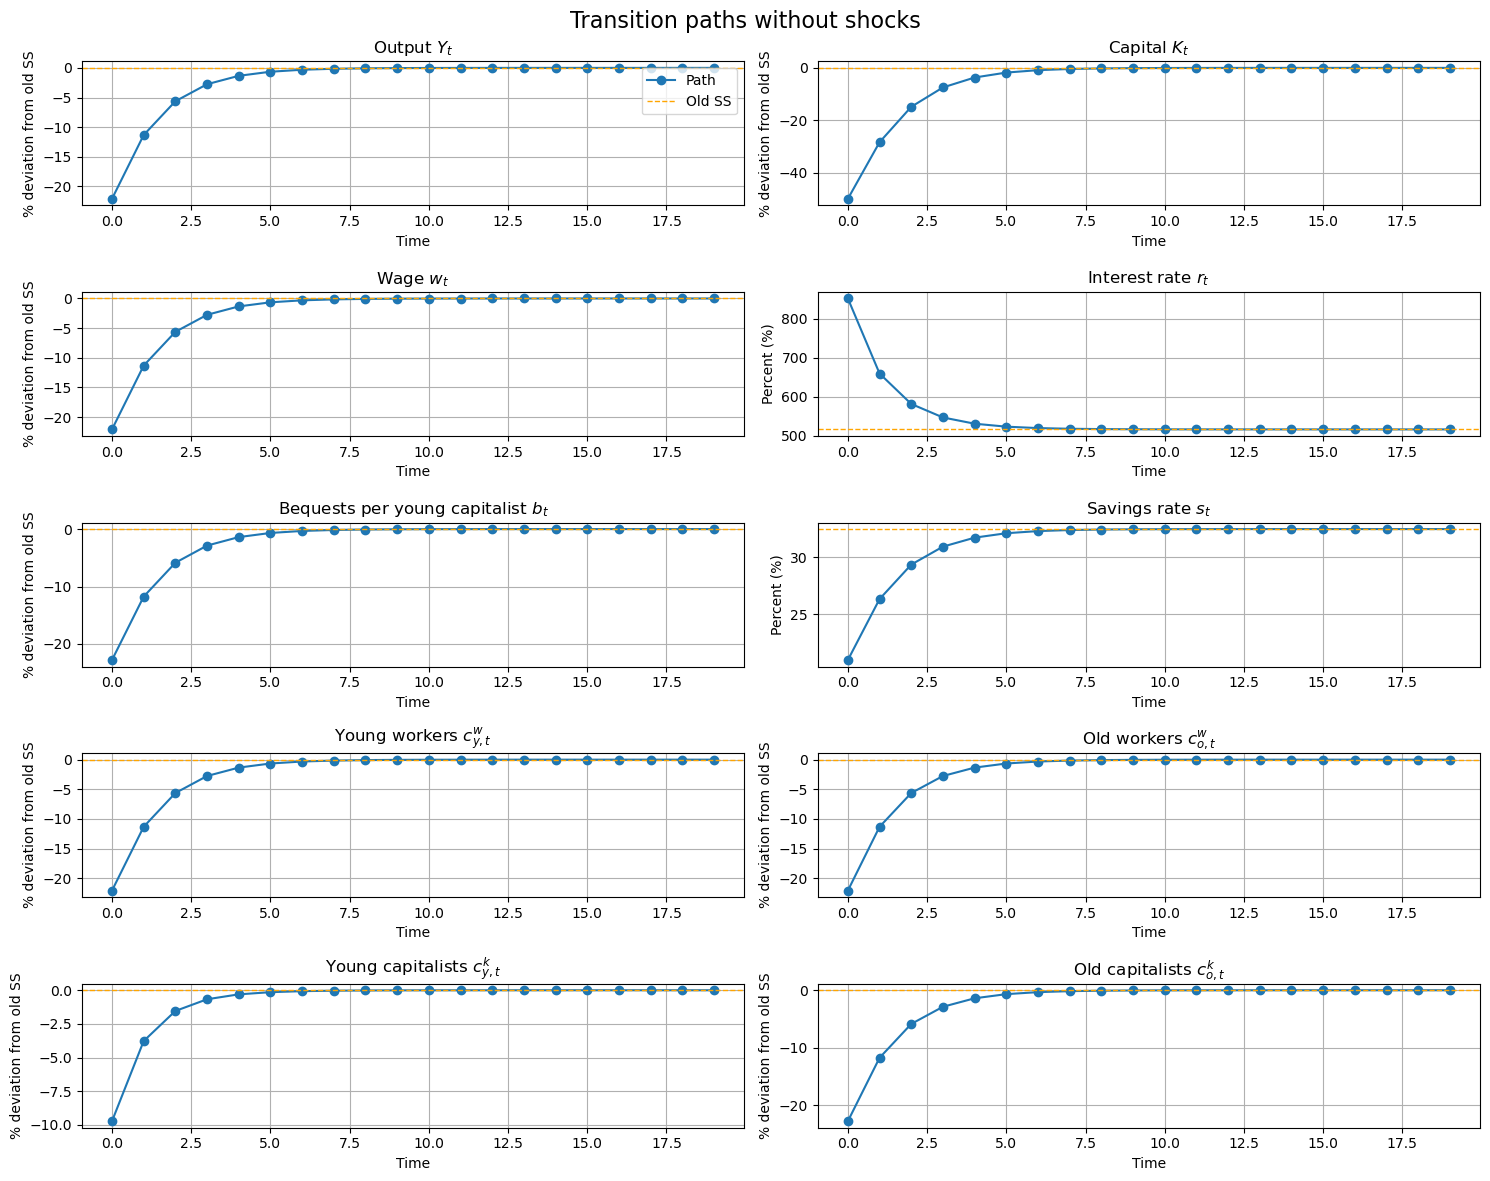

In [16]:
# Initialize a steady state, start at half of the steady-state capital to see a transition
eq = compute_steady_state(par)
K0 = .5 * eq.K
sim = simulate_olg(K0, T=20, par=par)
# Call plot function (Wealth tax and uncertainty False as default)
plot_simulation(eq, sim)

## Part 4

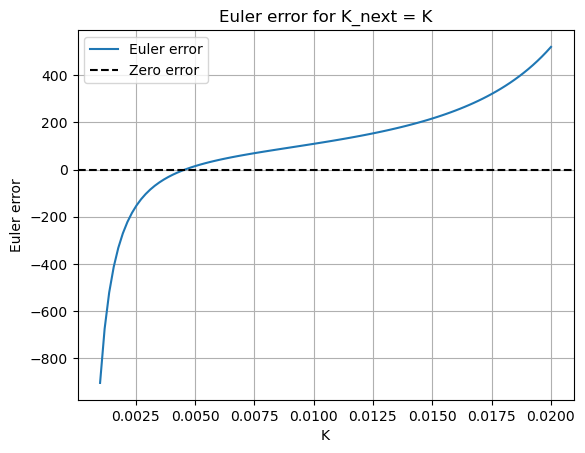

In [17]:
# 1. Parameters updated, added wealth tax rate
# 2. Functions modified to handle case with or without wealth tax

# Sanity-check (REMOVE LATER???)
K_grid = np.linspace(0.001, 0.02, 100)
# Values of K on this grid are very small, but that follows from large delta and 30-year periods.
euler_errors = [euler_err(K, K, par, wealth_tax=True) for K in K_grid]

plt.plot(K_grid, euler_errors, label='Euler error')
plt.axhline(0, color='k', linestyle='--', label='Zero error')
plt.xlabel('K')
plt.ylabel('Euler error')
plt.title('Euler error for K_next = K')
plt.legend()
_ = plt.grid()

In [18]:
# 3. Compute and print the steady state with wealth tax
eq = compute_steady_state(par, wealth_tax=True)
print_steady_state(eq)

Steady State Values:
 Values specified in question:
    Output (Y): 0.0800
    Capital (K): 0.0046
    Wage (w): 0.1280
    Interest Rate (r): 545.3349%
    Annualized Interest Rate: 6.4125%
    Consumption of Young Workers (c_wy): 0.0910
    Consumption of Old Workers (c_wo): 0.0399
    Consumption of Young Capitalists (c_ky): 0.0959
    Consumption of Old Capitalists (c_ko): 0.1416
    Asset Holdings per Young Capitalist (a): 0.0457
    Savings Rate (s): 32.2830%
-----------------------------
 Other values
    Labor (L): 0.4000 (Determined by model, only dependent on N_w)
    Capital-Labor Ratio (k): 0.0114
    Bequests per Young Capitalist (b): 0.1402
    Wealth Tax Transfer per Household (T_a): 0.0015


Savings and Capital stock go down very slightly, but basically an insignificant amount on both. 

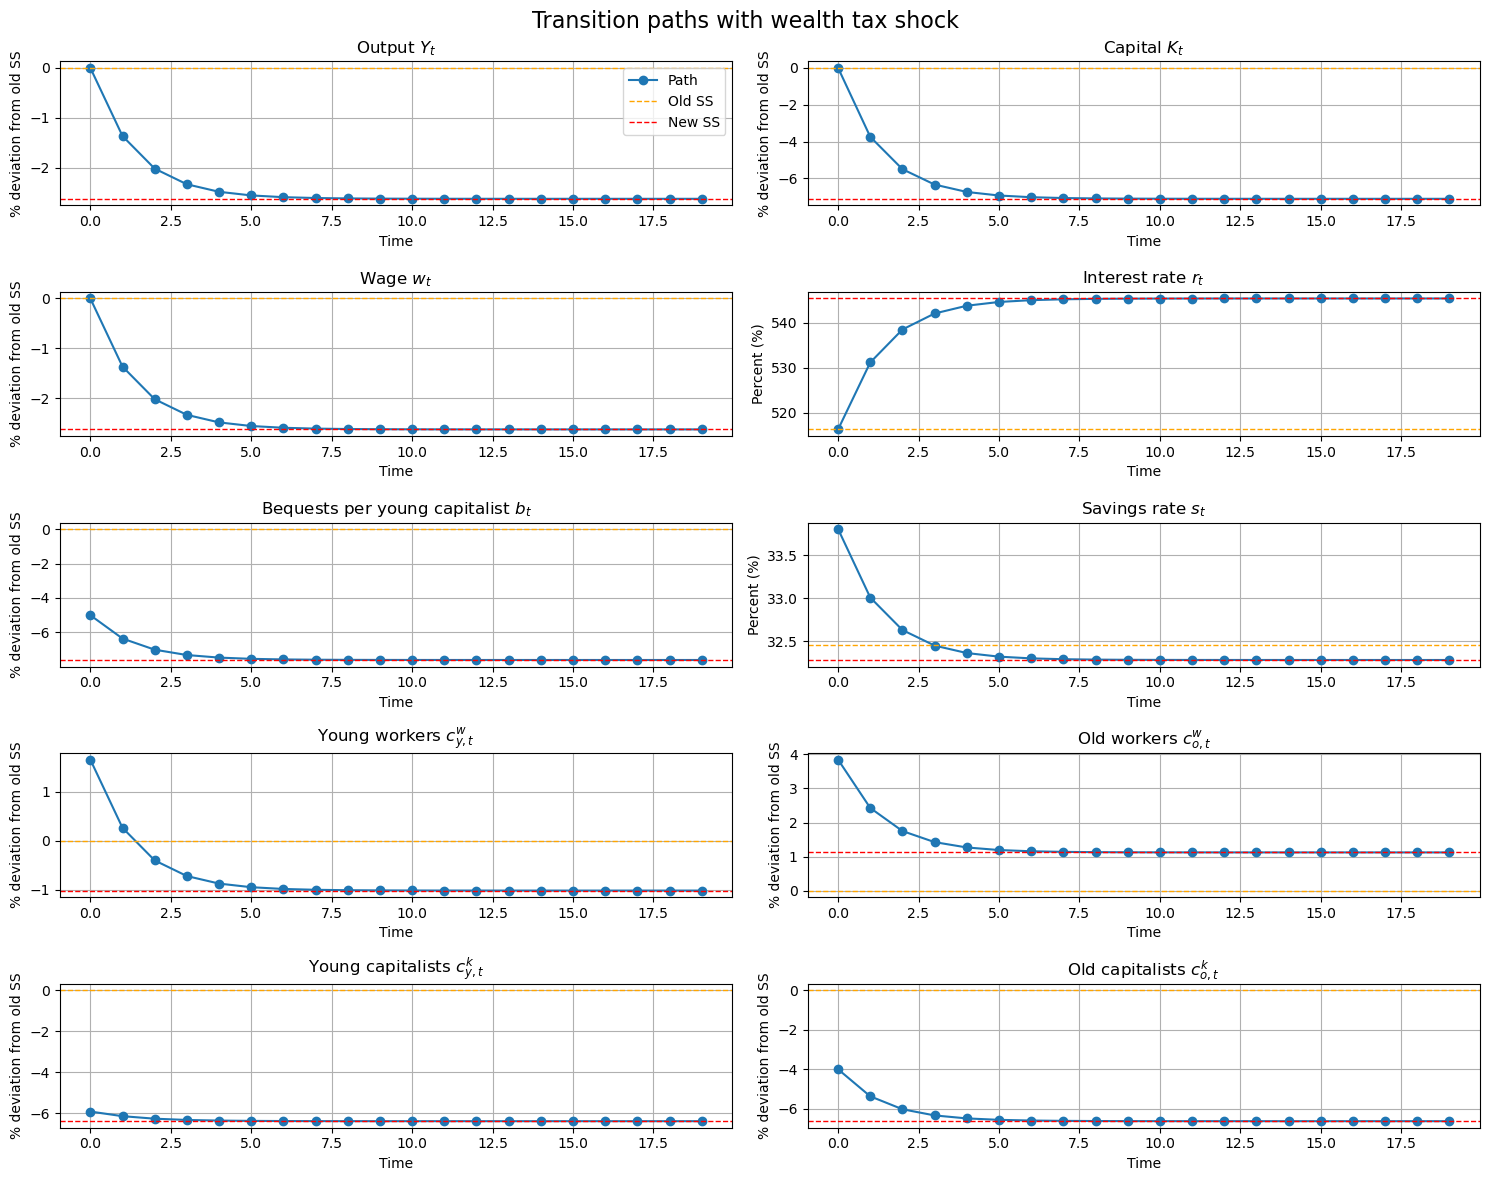

In [19]:
# 4. Simulate transition paths with wealth tax as shock in t=0, start at steady-state without wealth tax
eq_old = compute_steady_state(par, wealth_tax=False)
K0 = eq_old.K
sim = simulate_olg(eq_old.K, T=20, par=par, wealth_tax=True)
eq_new = compute_steady_state(par, wealth_tax=True)

# 5. Plot transition paths with both old and new SS
plot_simulation(eq_old, sim, eq_new, wealth_tax=True)

### 6. INTERPRETATION

## Part 5

In [20]:
# 1. Compute Social welfare for SS with/without wealth tax
def compute_social_welfare(par: Parameters, wealth_tax=False):
    """
    Compute the social welfare in the steady state, which is the sum of utilities of all agents.
    """
    # Steady-state instance
    eq = compute_steady_state(par, wealth_tax=wealth_tax)
    # CRRA Lifetime Utility of each type, dependent on gamma = 1 or not
    if par.gamma == 1:
        U_wo = np.log(eq.c_wo)
        U_wy = np.log(eq.c_wy) + par.beta * U_wo
        U_ko = np.log(eq.c_ko)
        U_ky = np.log(eq.c_ky) + par.beta * U_ko
    else:
        U_wo = eq.c_wo**(1 - par.gamma) / (1 - par.gamma)
        U_wy = eq.c_wy**(1 - par.gamma) / (1 - par.gamma) + par.beta * U_wo
        U_ko = eq.c_ko**(1 - par.gamma) / (1 - par.gamma)
        U_ky = eq.c_ky**(1 - par.gamma) / (1 - par.gamma) + par.beta * U_ko

    # Population weights
    N_w = eq.par.N_w
    N_k = eq.par.N_k

    # Social welfare as population-weighted sum of utilities
    SW = .5 * N_w * (U_wy + U_wo) + .5 * N_k * (U_ky + U_ko)

    return SW

In [21]:
SW_no_tax = compute_social_welfare(par, wealth_tax=False)
SW_with_tax = compute_social_welfare(par, wealth_tax=True)
print(f'Social welfare without wealth tax: {SW_no_tax:.4f}')
print(f'Social welfare with wealth tax: {SW_with_tax:.4f}')

Social welfare without wealth tax: -29.5652
Social welfare with wealth tax: -29.5342


Social welfare slightly lower/higher??? WITH wealth tax. Likely driven by capitalists.

In [22]:
# 2. Find socially optimal wealth tax rate by maximization as function of tau_a
def max_social_welfare(tau_a, par: Parameters):
    """
    Find optimal tau_a for Social Welfare.
    """
    # Define bounds for tau_a (by definition, it should be between 0 and 1)
    bounds = (0, 1)

    # Store original tau_a, to restore later
    tau_a_orig = par.tau_a

    # Objective function to minimize (negative social welfare for maximization)
    def objective(tau_a):
        # Temporarily overwriting tau_a for social welfare computation
        par.tau_a = float(tau_a)
        SW = compute_social_welfare(par, wealth_tax=True)
        return -SW  

    # Call a minimizer
    res = minimize_scalar(
        objective,
        bounds=bounds,
        method='bounded',
    )

    # Restore original tau_a to parameters
    par.tau_a = tau_a_orig

    # Check if optimization was successful
    if not res.success:
        print('Minimizer exited without success')
        print(res.message)

    # Recover optimal values
    tau_a_opt = res.x
    SW_opt = -res.fun

    return tau_a_opt, SW_opt

In [23]:
# Compute and print optimal wealth tax rate and corresponding social welfare
tau_a_opt, SW_opt = max_social_welfare(par.tau_a, par)
print(f'Optimal wealth tax rate (tau_a): {tau_a_opt:.4%}')
print(f'Max social welfare at optimal tau_a: {SW_opt:.4f}')

Optimal wealth tax rate (tau_a): 4.0558%
Max social welfare at optimal tau_a: -29.5324


# SANITY CHECK BELOW - REMOVE LATER

In [24]:
# Plot SW over a grid of wealth tax to visualize the maximization
def plot_SW_over_tau_grid(par: Parameters, wealth_tax=True):
    """
    Plot social welfare over a grid of wealth tax rates, to visualize the maximization and confirm the optimal tau_a exists.
    """
    # store original tau_a
    tau_a_orig = par.tau_a

    # grid for tau_a
    tau_grid = np.linspace(0.0, 0.1, 50)
    SW_vals = np.empty_like(tau_grid)

    for i, tau in enumerate(tau_grid):
        par.tau_a = float(tau)
        SW_vals[i] = compute_social_welfare(par, wealth_tax=wealth_tax)

    # restore original
    par.tau_a = tau_a_orig

    plt.figure(figsize=(6,4))
    plt.plot(tau_grid, SW_vals, marker='o')
    plt.axvline(tau_a_orig, color='orange', linestyle='--', label=r'current $\tau_a$')
    plt.xlabel(r'Wealth tax $\tau_a$')
    plt.ylabel('Social welfare SW')
    plt.title('Social welfare over wealth-tax grid')
    plt.grid(True)
    plt.legend()
    if tau_a_opt is not None:
        plt.axvline(tau_a_opt, color='red', linestyle='--', label=r'optimal $\tau_a$')
        plt.legend()
    plt.tight_layout()
    plt.show()

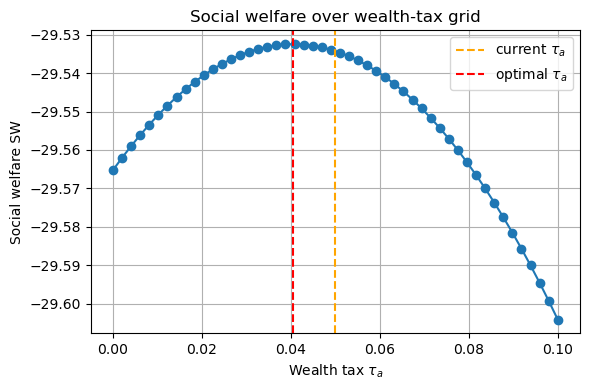

In [25]:
plot_SW_over_tau_grid(par, wealth_tax=True)

In [26]:
# 3. Solve for SS with optimal tau_a, report %-change in Y and K from original SS without wealth tax
eq_old = compute_steady_state(par, wealth_tax=False)

# Separate parameters instance to not overwrite original tau_a with optimal tau_a
par_opt_tau = Parameters()
par_opt_tau.tau_a = tau_a_opt
eq_new = compute_steady_state(par_opt_tau, wealth_tax=True)

# Report %-change in Y and K
pct_change_Y = 100 * (eq_new.Y - eq_old.Y) / eq_old.Y
pct_change_K = 100 * (eq_new.K - eq_old.K) / eq_old.K
print(f'Percent change in output Y from old to new SS: {pct_change_Y:.4f}%')
print(f'Percent change in capital K from old to new SS: {pct_change_K:.4f}%')

Percent change in output Y from old to new SS: -2.1220%
Percent change in capital K from old to new SS: -5.7839%


Both Output and Capital are lower, but Social Welfare is higher because the distribution of output is better in this case. 

## Part 6

In [27]:
# 1. Update parameters class where it is defined (DONE: added pi_a)
# 2. Implement euler_err_uncertain function (DONE: At the top, after euler_err)

In [28]:
# 3. Compute new steady state with uncertainty about wealth tax
eq_uncertain = compute_steady_state(par, wealth_tax=False, uncertainty=True)
print_steady_state(eq_uncertain)

Steady State Values:
 Values specified in question:
    Output (Y): 0.0796
    Capital (K): 0.0045
    Wage (w): 0.1273
    Interest Rate (r): 550.8801%
    Annualized Interest Rate: 6.4429%
    Consumption of Young Workers (c_wy): 0.0891
    Consumption of Old Workers (c_wo): 0.0382
    Consumption of Young Capitalists (c_ky): 0.1017
    Consumption of Old Capitalists (c_ko): 0.1468
    Asset Holdings per Young Capitalist (a): 0.0451
    Savings Rate (s): 30.7276%
-----------------------------
 Other values
    Labor (L): 0.4000 (Determined by model, only dependent on N_w)
    Capital-Labor Ratio (k): 0.0113
    Bequests per Young Capitalist (b): 0.1468
    No wealth tax implemented.


This steady-state, with uncertainty about future wealth tax but no actual wealth tax at any point, is not identical to the original from part 2. It seems to lie between the original without wealth tax and the second SS with wealth tax.

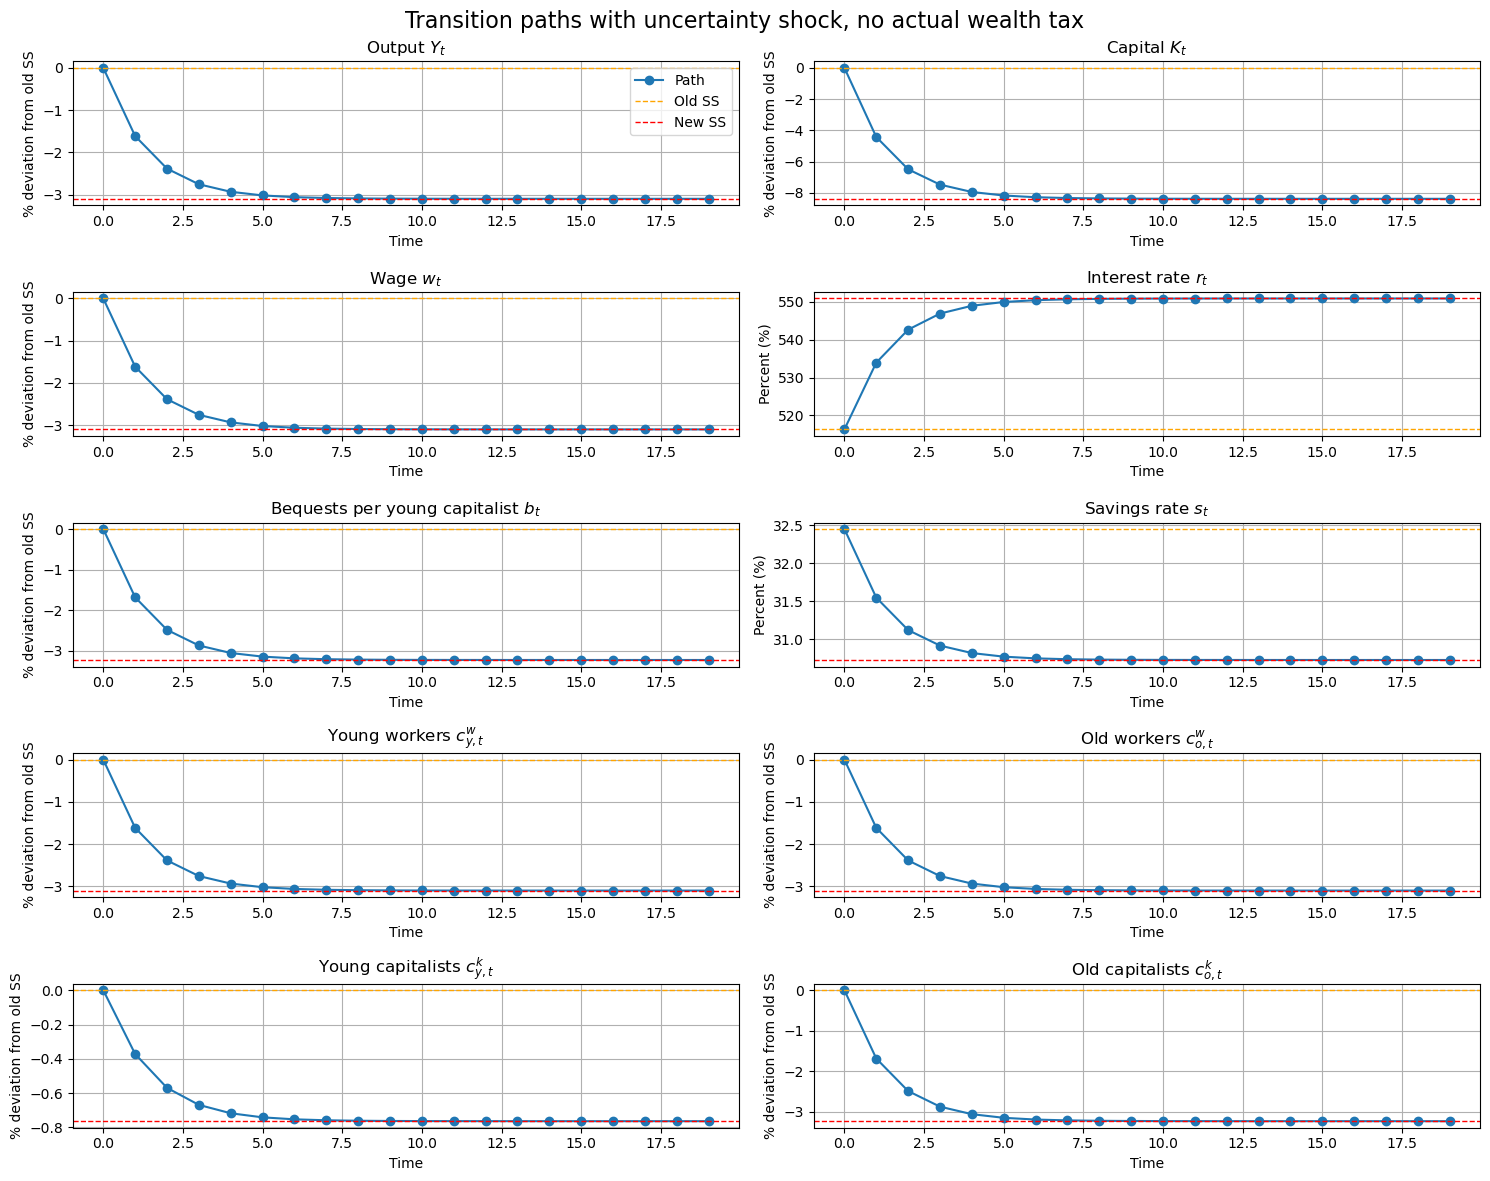

In [29]:
# Simulate and plot transition when uncertainty enters as a shock in period 0, but no actual wealth tax
eq_old = compute_steady_state(par, wealth_tax=False, uncertainty=False)
K0 = eq_old.K
sim_uncertain = simulate_olg(K0, T=20, par=par, wealth_tax=False, uncertainty=True)
plot_simulation(eq_old, sim_uncertain, eq_uncertain, wealth_tax=False, uncertainty=True)